In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys


def get_dir_n_levels_up(path, n):
    # Go up n levels from the given path
    for _ in range(n):
        path = os.path.dirname(path)
    return path

proj_root = get_dir_n_levels_up(os.path.abspath("__file__"), 3)
sys.path.append(proj_root)

,seed,N,v_L1_final,A_Fro_final,A_MAE_final,mean_oracle_end,mean_learn_end,mean_noc_end,mean_gap_to_oracle_end,mean_err_avg,mean_err_max,vx_gap_to_oracle_end,vx_err_avg,vx_err_max
0,0,15,0.242491,2.037883,0.062395,0.613426,0.612758,0.364735,6.678498e-04,2.898134e-04,8.609631e-04,2.520763e-04,1.276272e-04,4.001725e-04
1,1,15,0.280827,1.350734,0.048868,0.617581,0.603602,0.379051,1.397833e-02,8.535272e-03,1.397833e-02,1.434530e-02,9.315694e-03,1.434530e-02
2,2,15,0.245814,1.414175,0.045892,0.632427,0.632427,0.379802,9.416806e-10,4.947891e-10,9.416806e-10,7.989494e-10,4.203163e-10,7.989494e-10
3,3,15,0.193324,1.049470,0.039676,0.627068,0.619628,0.388790,7.440099e-03,4.846160e-03,9.090082e-03,7.754954e-03,5.425309e-03,1.051275e-02
4,4,15,0.602545,1.441575,0.044787,0.635532,0.603921,0.347420,3.161114e-02,1.175978e-02,3.161114e-02,4.484067e-02,2.065976e-02,4.484067e-02
5,5,15,0.322736,1.413743,0.048201,0.668751,0.622986,0.424340,4.576541e-02,2.417450e-02,4.576541e-02,4.227012e-02,2.314142e-02,4.227012e-02
6,6,15,0.455128,1.078219,0.030280,0.650405,0.614772,0.369122,3.563303e-02,2.094438e-02,3.563303e-02,4.421828e-02,3.106840e-02,4.826203e-02
7,7,15,0.201403,1.352198,0.046148,0.622755,0.607382,0.395018,1.537344e-02,9.836674e-03,1.715542e-02,1.548000e-02,1.063168e-02,1.790590e-02
8,8,15,0.254226,1.213002,0.042417,0.624608,0.610463,0.393937,1.414538e-02,7.540940e-03,1.414538e-02,1.409632e-02,7.762300e-03,1.409632e-02
9,9,15,0.273246,1.752168,0.058474,0.608649,0.606297,0.368423,2.352075e-03,1.299180e-03,2.352075e-03,2.127977e-03,1.250535e-03,2.127977e-03



=== Aggregate (across seeds) ===


,count,mean,std,min,25%,50%,75%,max
v_L1_final,10.0,0.307174,0.127420,1.933240e-01,0.243321,0.263736,0.312258,0.602545
A_Fro_final,10.0,1.410317,0.297782,1.049470e+00,1.247435,1.382971,1.434725,2.037883
A_MAE_final,10.0,0.046714,0.009030,3.028025e-02,0.043010,0.046020,0.048701,0.062395
mean_gap_to_oracle_end,10.0,0.016697,0.015877,9.416806e-10,0.003624,0.014062,0.027552,0.045765
mean_err_avg,10.0,0.008923,0.008280,4.947891e-10,0.002186,0.008038,0.011279,0.024174
vx_gap_to_oracle_end,10.0,0.018539,0.018333,7.989494e-10,0.003535,0.014221,0.035573,0.044841
vx_err_avg,10.0,0.010938,0.010657,4.203163e-10,0.002294,0.008539,0.018153,0.031068


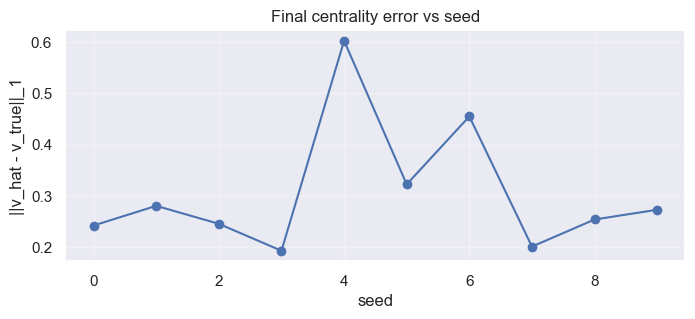

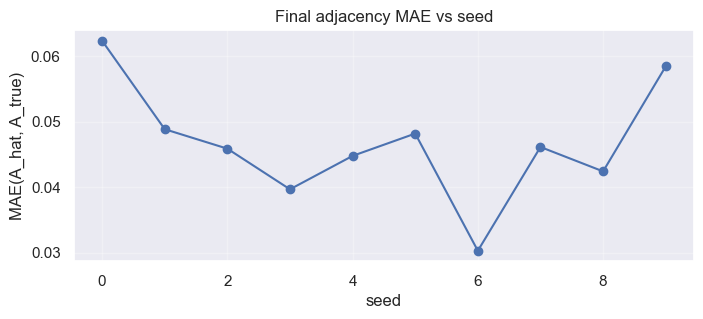

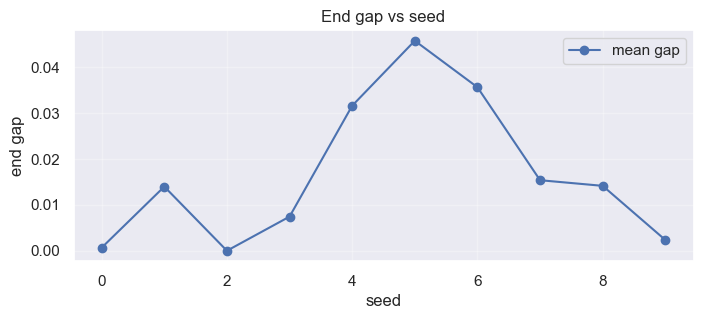

In [3]:
# =========================================================
# Multi-seed experiment (10 seeds) — collect metrics only
# =========================================================

import matplotlib.pyplot as plt

# Your identification + control pieces (from your repo)

from opinion_dynamics.experiments.online import run_multi_seed_experiment, run_single_seed_experiment
# from opinion_dynamics.experiments.rollouts import rollout_with_policy_intermediate
# from opinion_dynamics.experiments.metrics import graph_sanity


# =========================================================
# Run it
# =========================================================
df = run_multi_seed_experiment(
    seeds=range(10),
    B_campaign=1.0,
    num_campaigns_total=5,
    lr=1e-3,
    l2_lambda=0.0,
    device="cpu",
    update_A_each_campaign=True,
    suppress_fit_logs=True,
)

display(df)

print("\n=== Aggregate (across seeds) ===")
cols = ["v_L1_final","A_Fro_final","A_MAE_final","mean_gap_to_oracle_end","mean_err_avg","vx_gap_to_oracle_end","vx_err_avg"]
display(df[cols].describe().T)

# =========================================================
# Quick plots to inspect variability across seeds
# (matplotlib default colors as requested)
# =========================================================
plt.figure(figsize=(8,3))
plt.plot(df["seed"], df["v_L1_final"], marker="o")
plt.xlabel("seed"); plt.ylabel("||v_hat - v_true||_1")
plt.title("Final centrality error vs seed")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8,3))
plt.plot(df["seed"], df["A_MAE_final"], marker="o")
plt.xlabel("seed"); plt.ylabel("MAE(A_hat, A_true)")
plt.title("Final adjacency MAE vs seed")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8,3))
plt.plot(df["seed"], df["mean_gap_to_oracle_end"], marker="o", label="mean gap")
plt.xlabel("seed"); plt.ylabel("end gap")
plt.title("End gap vs seed")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

=== METRICS ===
{'seed': 6, 'dynamics': 'laplacian', 'N': 15, 'v_L1_final': 0.5997821369683729, 'A_Fro_final': 1.297481660018266, 'A_MAE_final': 0.040216543364249874, 'mean_oracle_end': 0.6504051933351345, 'mean_learn_end': 0.6072805265304193, 'mean_noc_end': 0.3691217017305383, 'mean_gap_to_oracle_end': 0.04312466680471516, 'mean_err_avg': 0.023848633288611688, 'mean_err_max': 0.04312466680471516, 'vx_gap_to_oracle_end': 0.05144357182857717, 'vx_err_avg': 0.03371325667243679, 'vx_err_max': 0.05176947380447261}

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 1.053195071273723
edges: 38
sink_sizes: [11]
has_singleton_sink: False

=== GRAPH SANITY (LEARNED FINAL) ===
diag_max: 0.0
row_sum_min: 0.9999998962448444
row_sum_mean: 0.9999999859447901
row_sum_max: 1.0000001024454832
asym: 1.1287873613053947
edges: 210
sink_sizes: [15]
has_singleton_sink: False


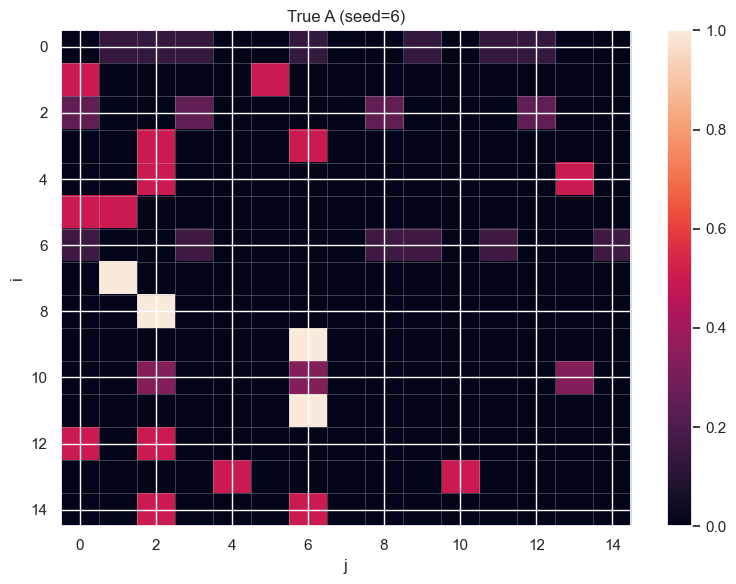

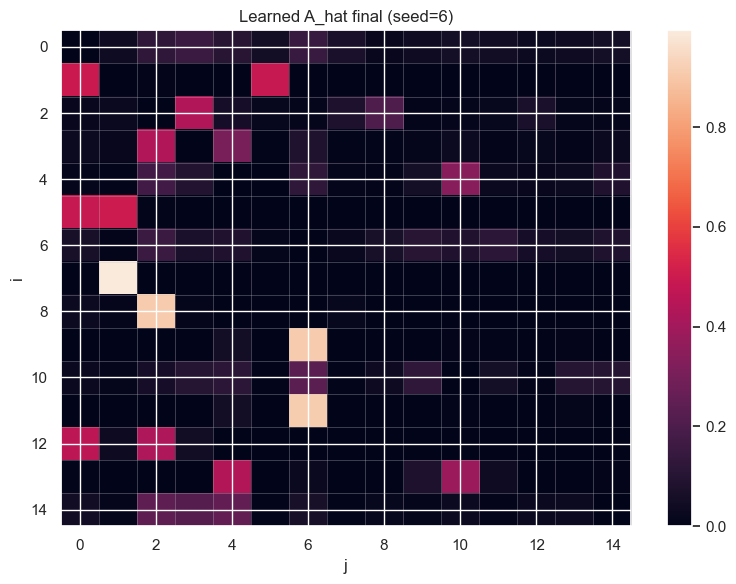

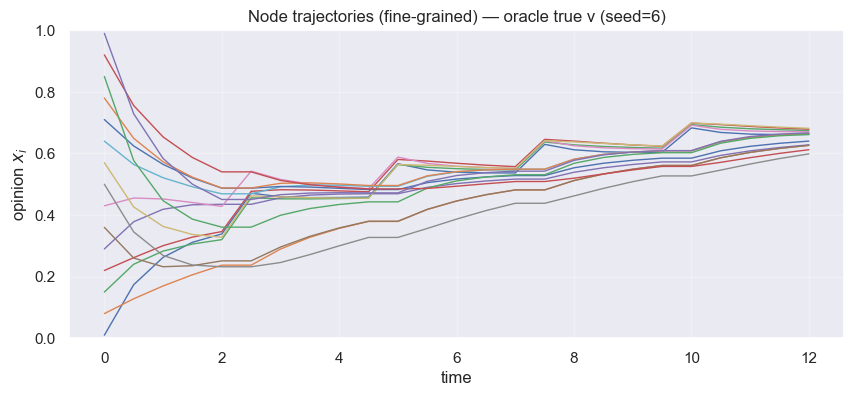

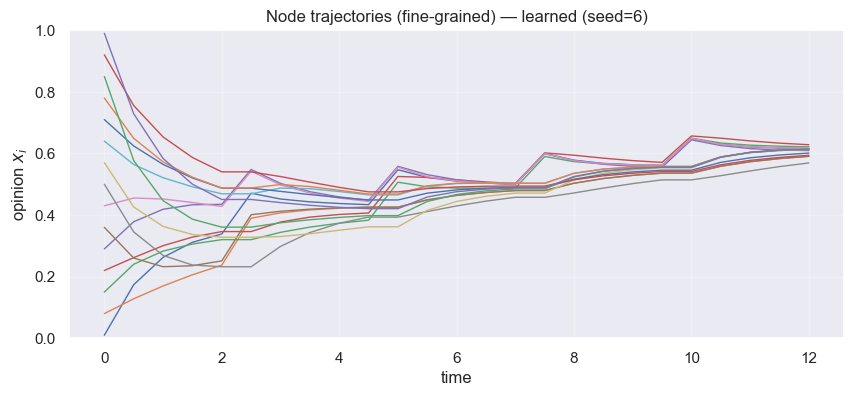


=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat - v_true): 0.5997821369683729


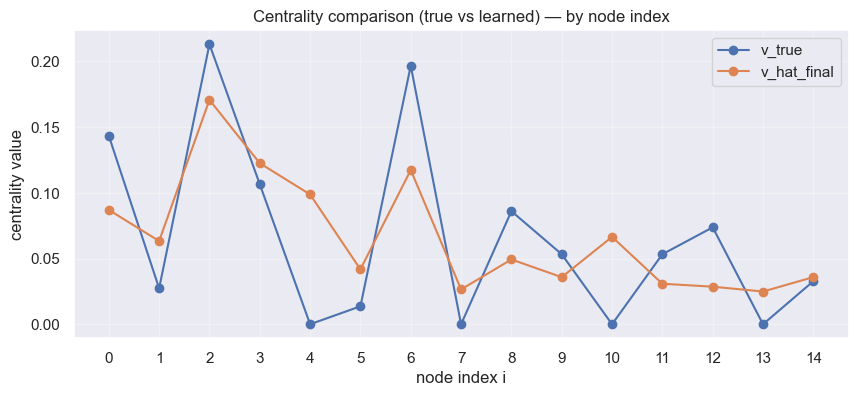

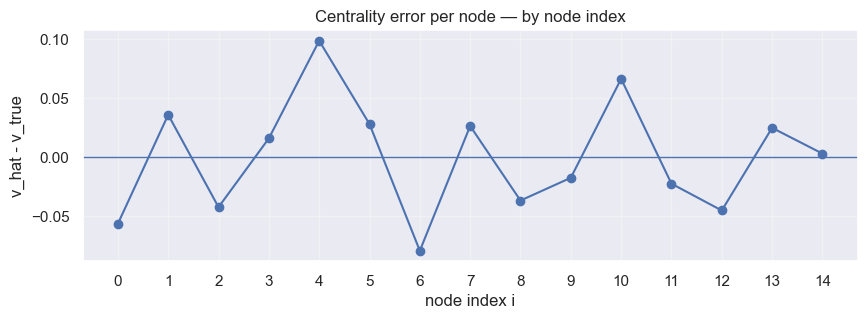

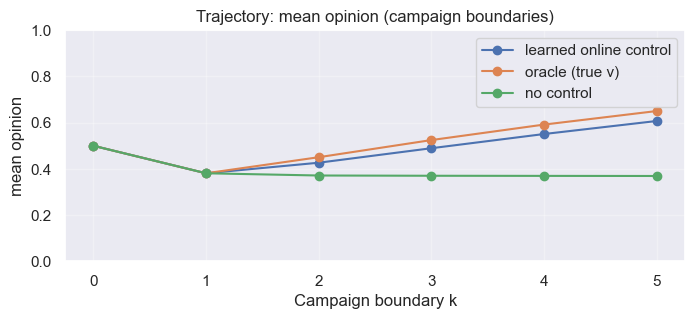

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from rl_envs_forge.envs.network_graph.graph_utils import compute_laplacian, compute_eigenvector_centrality

from opinion_dynamics.experiments.plots import (
    plot_impulse_node_trajectories,
    show_matrix_with_cell_grid,
    concat_intermediate
)
from opinion_dynamics.experiments.metrics import graph_sanity
from opinion_dynamics.experiments.rollouts import rollout_with_v_intermediate
from opinion_dynamics.experiments.online import run_single_seed_experiment


SEED_TO_PLOT = 6
B_campaign = 1.0
num_campaigns_total = 5

metrics, art = run_single_seed_experiment(
    seed=SEED_TO_PLOT,
    B_campaign=B_campaign,
    num_campaigns_total=num_campaigns_total,
    lr=1e-3,
    l2_lambda=0.0,
    device="cpu",
    update_A_each_campaign=True,
    suppress_fit_logs=True,
    return_artifacts=True,
)

print("=== METRICS ===")
print(metrics)

env = art["env"]

# -----------------------------
# True graph + v_true (env-consistent)
# -----------------------------
A_true = np.asarray(art["A_true"], dtype=float)
v_true = np.asarray(art["v_true"], dtype=float)

A_hat_final = np.asarray(art["A_hat_final"], dtype=float)
v_hat_final = np.asarray(art["v_hat_final"], dtype=float)

# -----------------------------
# GRAPH SANITY
# -----------------------------
print("\n=== GRAPH SANITY (TRUE) ===")
for k, v in graph_sanity(A_true).items():
    print(f"{k}: {v}")

print("\n=== GRAPH SANITY (LEARNED FINAL) ===")
for k, v in graph_sanity(A_hat_final).items():
    print(f"{k}: {v}")

# -----------------------------
# Heatmaps (true vs learned-final)
# -----------------------------
show_matrix_with_cell_grid(A_true,      title=f"True A (seed={SEED_TO_PLOT})")
show_matrix_with_cell_grid(A_hat_final, title=f"Learned A_hat final (seed={SEED_TO_PLOT})")

# -----------------------------
# Learned run: fine-grained impulse trajectories
# (this is what your plot_impulse_node_trajectories expects)
# -----------------------------
inter_list = art["intermediate_states_list"]   # list length K, each (T_k, N)
time_list  = art["intermediate_times_list"]    # list length K, each (T_k,)

valid_pairs = [(xs, ts) for xs, ts in zip(inter_list, time_list) if xs is not None and ts is not None]
if not valid_pairs:
    raise RuntimeError("No intermediate trajectories found. env.step must return info['intermediate_states'].")

lengths = [xs.shape[0] for xs, _ in valid_pairs]
same_len = all(L == lengths[0] for L in lengths)

if same_len:
    inter_learn = np.stack([xs for xs, _ in valid_pairs], axis=0)   # (K, T, N)
    times_learn = np.stack([ts for _, ts in valid_pairs], axis=0)   # (K, T)
else:
    # If lengths differ per campaign, we can't stack into (K,T,N).
    # We'll plot per-campaign instead.
    inter_learn = None
    times_learn = None

# -----------------------------
# Oracle + no-control rollouts WITH intermediate (using new function)
# -----------------------------
states_learn = np.asarray(art["states_learn"], dtype=float)
x0 = art["x0"]
K_total = states_learn.shape[0] - 1  # campaigns actually run

or_out = rollout_with_v_intermediate(env, x0, K_total, B_campaign, v_true)
nc_out = rollout_with_v_intermediate(env, x0, K_total, B_campaign, None)

# -----------------------------
# Oracle + no-control rollouts WITH intermediate
# -----------------------------
states_learn = np.asarray(art["states_learn"], dtype=float)
x0 = art["x0"]
K_total = states_learn.shape[0] - 1

or_out = rollout_with_v_intermediate(env, x0, K_total, B_campaign, v_true, zero_first_campaign=True)
nc_out = rollout_with_v_intermediate(env, x0, K_total, B_campaign, None,   zero_first_campaign=True)

# -----------------------------
# Concatenate to (T_total,N) so plot_impulse_node_trajectories behaves
# -----------------------------
dt = getattr(env, "t_s", None)

X_or, T_or = concat_intermediate(
    or_out["intermediate_states_list"],
    or_out["intermediate_times_list"],
    dt=dt,
)

X_le, T_le = concat_intermediate(
    art["intermediate_states_list"],
    art["intermediate_times_list"],
    dt=dt,
)

plot_impulse_node_trajectories(X_or, T_or, title=f"Node trajectories (fine-grained) — oracle true v (seed={SEED_TO_PLOT})")
plot_impulse_node_trajectories(X_le, T_le, title=f"Node trajectories (fine-grained) — learned (seed={SEED_TO_PLOT})")

# -----------------------------
# Centrality comparison plots (like your simple experiment)
# -----------------------------
print("\n=== CENTRALITY COMPARISON (by node index) ===")
print("L1(v_hat - v_true):", float(np.sum(np.abs(v_hat_final - v_true))))

idx = np.arange(len(v_true))
diff = v_hat_final - v_true

plt.figure(figsize=(10, 4))
plt.plot(idx, v_true, marker="o", label="v_true")
plt.plot(idx, v_hat_final, marker="o", label="v_hat_final")
plt.xlabel("node index i")
plt.ylabel("centrality value")
plt.title("Centrality comparison (true vs learned) — by node index")
plt.xticks(idx)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 3))
plt.axhline(0.0, linewidth=1)
plt.plot(idx, diff, marker="o")
plt.xlabel("node index i")
plt.ylabel("v_hat - v_true")
plt.title("Centrality error per node — by node index")
plt.xticks(idx)
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# Mean opinion plot (campaign boundaries)
# -----------------------------
states_oracle = np.asarray(or_out["states"], dtype=float)
states_noc    = np.asarray(nc_out["states"], dtype=float)

mean_learn = states_learn.mean(axis=1)
mean_or    = states_oracle.mean(axis=1)
mean_nc    = states_noc.mean(axis=1)

plt.figure(figsize=(8, 3))
plt.plot(mean_learn, marker="o", label="learned online control")
plt.plot(mean_or, marker="o", label="oracle (true v)")
plt.plot(mean_nc, marker="o", label="no control")
plt.xlabel("Campaign boundary k")
plt.ylabel("mean opinion")
plt.title("Trajectory: mean opinion (campaign boundaries)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 1)
plt.show()